# Autoencoder

Implementation of an autoencoder tested on the MNIST images dataset. Paper links:

AE - [Paper](https://www.cs.toronto.edu/~hinton/absps/science.pdf) <br>
DAE - [Paper](https://www.cs.toronto.edu/~larocheh/publications/icml-2008-denoising-autoencoders.pdf) <br>
MAE - [Paper](https://arxiv.org/pdf/2111.06377.pdf) <br>

### 1) Autoencoder for Compression

Autoencoder with a compressed latent space. Using Convolution for downscaling and Deconvolution for upscaling.

Model trained on MNIST images.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.optim as optim
import sklearn.cluster as cluster

In [3]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


In [4]:
class Encoder(nn.Module):
    def __init__(self, conv_1, conv_2, conv_3):
        super().__init__()
        self.conv_1 = nn.Conv2d(1, conv_1, kernel_size=9)
        self.conv_2 = nn.Conv2d(conv_1, conv_2, kernel_size=7)
        self.conv_3 = nn.Conv2d(conv_2, conv_3, kernel_size=7)
        
    
    def forward(self, x):
        x = F.relu(self.conv_1(x))
        x = F.relu(self.conv_2(x))
        x = F.relu(self.conv_3(x))
        return x

In [5]:
class Decoder(nn.Module):
    def __init__(self, deconv_1, deconv_2, deconv_3, out_dim):
        super().__init__()
        self.deconv_1 = nn.ConvTranspose2d(deconv_1, deconv_2, kernel_size=7)
        self.deconv_2 = nn.ConvTranspose2d(deconv_2, deconv_3, kernel_size=7)
        self.deconv_3 = nn.ConvTranspose2d(deconv_3, out_dim, kernel_size=9)

    def forward(self, x):
        x = F.relu(self.deconv_1(x))
        x = F.relu(self.deconv_2(x))
        x = F.relu(self.deconv_3(x))
        return x

tensor(0.1081, grad_fn=<MseLossBackward0>)
tensor(0.0405, grad_fn=<MseLossBackward0>)
tensor(0.0258, grad_fn=<MseLossBackward0>)
tensor(0.0199, grad_fn=<MseLossBackward0>)
tensor(0.0183, grad_fn=<MseLossBackward0>)
tensor(0.0167, grad_fn=<MseLossBackward0>)
tensor(0.0146, grad_fn=<MseLossBackward0>)
tensor(0.0140, grad_fn=<MseLossBackward0>)
tensor(0.0141, grad_fn=<MseLossBackward0>)
tensor(0.0145, grad_fn=<MseLossBackward0>)
tensor(0.0131, grad_fn=<MseLossBackward0>)
tensor(0.0133, grad_fn=<MseLossBackward0>)
tensor(0.0118, grad_fn=<MseLossBackward0>)
tensor(0.0114, grad_fn=<MseLossBackward0>)
tensor(0.0114, grad_fn=<MseLossBackward0>)
tensor(0.0126, grad_fn=<MseLossBackward0>)
tensor(0.0098, grad_fn=<MseLossBackward0>)
tensor(0.0116, grad_fn=<MseLossBackward0>)
tensor(0.0106, grad_fn=<MseLossBackward0>)
tensor(0.0105, grad_fn=<MseLossBackward0>)


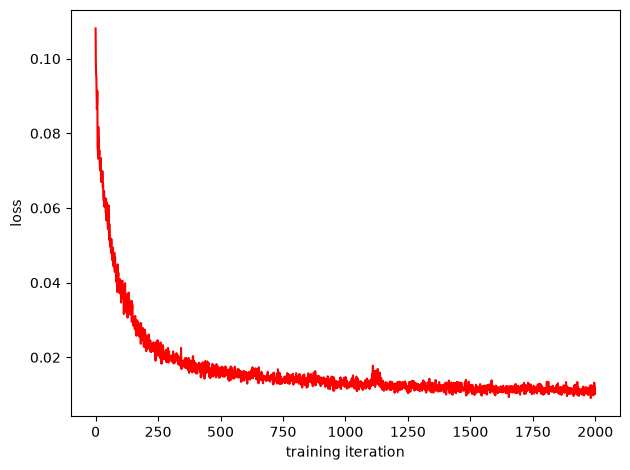

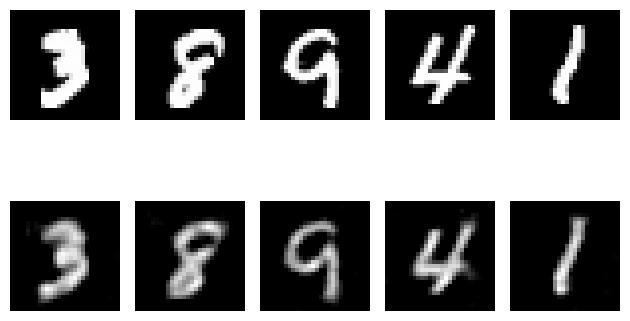

In [7]:
encoder = Encoder(8, 16, 6)
decoder = Decoder(6, 16, 8, 1)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
batch_nr = 2000
loss_function = nn.MSELoss()
optimiser = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),lr = 0.001)
loss_list = []

for j in range(batch_nr):
    train_features, _ = next(iter(train_dataloader))
    z = encoder(train_features)
    out = decoder(z)
    optimiser.zero_grad()
    loss = loss_function(out, train_features)
    loss_list.append(loss.detach())
    loss.backward()
    optimiser.step()
    if j %100 == 0:
        print(loss)
    
# Plot Loss
x_vals = np.arange(len(loss_list))
plt.plot(x_vals, loss_list, 'r')
plt.xlabel('training iteration')
plt.ylabel('loss')
plt.tight_layout()
plt.show()

# Plot pictures 
train_dataloader_plot = DataLoader(training_data, batch_size=5, shuffle=True)
train_features_plot, _ = next(iter(train_dataloader_plot))
for idx in range(5): 
    plt.subplot(2, 5, idx + 1) 
    plt.imshow(train_features_plot[idx].numpy()[0], cmap='gray') 
    plt.axis('off') 

for idx in range(5): 
    plt.subplot(2,5, 5+idx + 1) 
    z = encoder(train_features_plot)
    recon = decoder(z)
    plt.imshow(recon.detach().numpy()[idx][0], cmap="gray")
    plt.axis('off')
plt.tight_layout() 
plt.show() 

### 2) Denoising AE

Building a denoising autoencoder (DAE). The DAE may have more latent dimensions than input dimensions. The training on noisy inputs prevents it from learning the identity function. Therefore, using a bigger latent space is possible, too.

Again trained on MNIST samples that have two different flavours of noise applied to them.

In [9]:
class Enoiser(nn.Module):
    def __init__(self, conv_1, conv_2, conv_3):
        super().__init__()
        self.conv_1 = nn.Conv2d(1, conv_1, kernel_size=9)
        self.conv_2 = nn.Conv2d(conv_1, conv_2, kernel_size=7)
        self.conv_3 = nn.Conv2d(conv_2, conv_3, kernel_size=7)
        
    
    def forward(self, x):
        x = F.relu(self.conv_1(x))
        x = F.relu(self.conv_2(x))
        x = F.relu(self.conv_3(x))
        return x

In [10]:
class Denoiser(nn.Module):
    def __init__(self, deconv_1, deconv_2, deconv_3, out_dim):
        super().__init__()
        self.deconv_1 = nn.ConvTranspose2d(deconv_1, deconv_2, kernel_size=7)
        self.deconv_2 = nn.ConvTranspose2d(deconv_2, deconv_3, kernel_size=7)
        self.deconv_3 = nn.ConvTranspose2d(deconv_3, out_dim, kernel_size=9)
        #self.conv_1 = nn.Conv2d(deconv_3, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.relu(self.deconv_1(x))
        x = F.relu(self.deconv_2(x))
        x = F.relu(self.deconv_3(x))
        #x = F.relu(self.conv_1(x))
        return x

In [11]:
def gauss_noise(t, std, mean):
    return t + torch.randn(t.size()) * std + mean

tensor(0.1045, grad_fn=<MseLossBackward0>)
tensor(0.0449, grad_fn=<MseLossBackward0>)
tensor(0.0208, grad_fn=<MseLossBackward0>)
tensor(0.0136, grad_fn=<MseLossBackward0>)
tensor(0.0094, grad_fn=<MseLossBackward0>)
tensor(0.0110, grad_fn=<MseLossBackward0>)
tensor(0.0111, grad_fn=<MseLossBackward0>)
tensor(0.0082, grad_fn=<MseLossBackward0>)
tensor(0.0071, grad_fn=<MseLossBackward0>)
tensor(0.0071, grad_fn=<MseLossBackward0>)
tensor(0.0069, grad_fn=<MseLossBackward0>)
tensor(0.0062, grad_fn=<MseLossBackward0>)
tensor(0.0071, grad_fn=<MseLossBackward0>)
tensor(0.0082, grad_fn=<MseLossBackward0>)
tensor(0.0069, grad_fn=<MseLossBackward0>)
tensor(0.0059, grad_fn=<MseLossBackward0>)
tensor(0.0057, grad_fn=<MseLossBackward0>)
tensor(0.0065, grad_fn=<MseLossBackward0>)
tensor(0.0051, grad_fn=<MseLossBackward0>)
tensor(0.0050, grad_fn=<MseLossBackward0>)


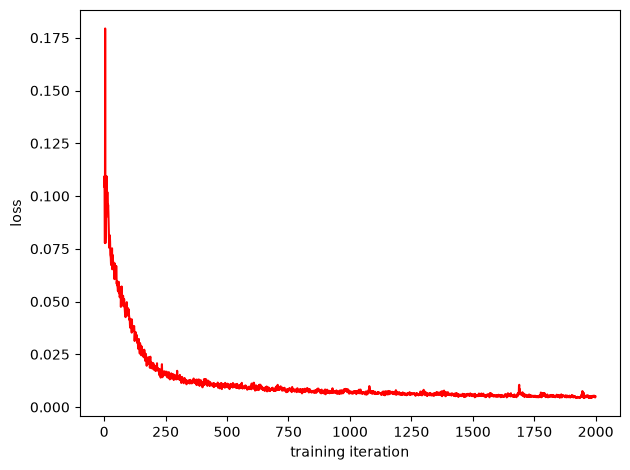

In [13]:
enoiser = Enoiser(8, 16, 32)
denoiser = Denoiser(32, 16, 8, 1)
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
batch_nr = 2000
loss_function = nn.MSELoss()
optimiser = optim.Adam(list(enoiser.parameters()) + list(denoiser.parameters()),lr = 0.001)
loss_list = []
for j in range(batch_nr):
    train_features, _ = next(iter(train_dataloader))
    train_features_noised = gauss_noise(gauss_noise(train_features, 0.01, 0.5),0.05, 0.4)
    z = enoiser(train_features_noised)
    out = denoiser(z)
    optimiser.zero_grad()
    loss = loss_function(out, train_features)
    loss_list.append(loss.detach())
    loss.backward()
    optimiser.step()
    if j%100 == 0:
        print(loss)

# Plot Loss
x_vals = np.arange(len(loss_list))
plt.plot(x_vals, loss_list, 'r')
plt.xlabel('training iteration')
plt.ylabel('loss')
plt.tight_layout()
plt.show()

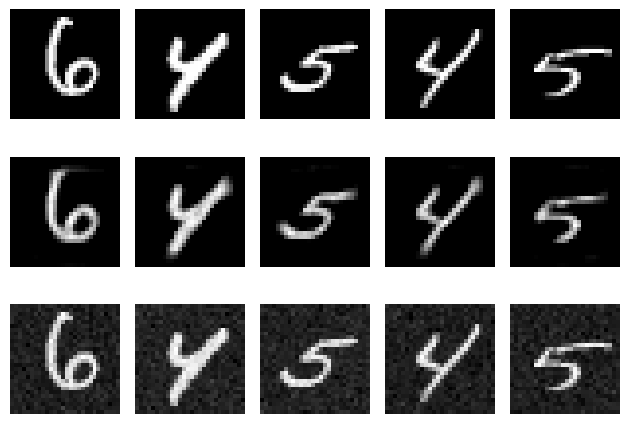

In [14]:
# Plot pictures 
train_features_plot, _ = next(iter(train_dataloader))
for idx in range(5): 
    plt.subplot(3, 5, idx + 1) 
    plt.imshow(train_features_plot[:5].numpy()[idx][0], cmap='gray') 
    plt.axis('off') 

for idx in range(5): 
    plt.subplot(3,5, 5+idx + 1) 
    train_features_noised_plot = gauss_noise(gauss_noise(train_features_plot, 0.01, 0.5),0.05, 0.4)
    z = enoiser(train_features_noised_plot)
    recon = denoiser(z)
    plt.imshow(recon.detach().numpy()[idx][0], cmap="gray")
    plt.axis('off')
    plt.subplot(3, 5, 10+idx + 1) 
    plt.imshow(train_features_noised_plot[:5].numpy()[idx][0], cmap='gray') 
    plt.axis('off')
    
    
plt.tight_layout() 
plt.show() 